In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [6]:
antibio = pd.read_csv("data/antibio.csv")
antibio_lm = ols("org ~ type", data = antibio).fit()

anova_tab = sm.stats.anova_lm(antibio_lm, type = 3)

print(anova_tab)

antibio_lm.summary()

            df    sum_sq   mean_sq         F   PR(>F)
type       5.0  0.590824  0.118165  7.972558  0.00009
Residual  28.0  0.415000  0.014821       NaN      NaN


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    org   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     7.973
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           8.95e-05
Time:                        13:02:16   Log-Likelihood:                 26.655
No. Observations:                  34   AIC:                            -41.31
Df Residuals:                      28   BIC:                            -32.15
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.8950      0.050     58.248      0.000       2.793       2.997
type[T.Control]     -0.2917      0.070     -4.150      0.000      -0.436      -0.148
type[T.Enroflox]    -0.1850      0.070     -2.632      0.014      -0.329      -0.041
type[T.Fenbenda]    -0.0617      0.070     -0.877      0.388      -0.206       0.082
type[T.Ivermect]     0.1067      0.070      1.518      0.140      -0.037       0.251
type[T.Spiramyc]    -0.0400      0.079     -0.509      0.615      -0.201       0.121
==============================================================================
Omnibus:                        2.172   Durbin-Watson:                   2.146
Prob(Omnibus):                  0.338   Jarque-Bera (JB):                1.704
Skew:                          -0.545   Prob(JB):                        0.427
Kurtosis:                       2.876   Cond. No.                         6.71
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

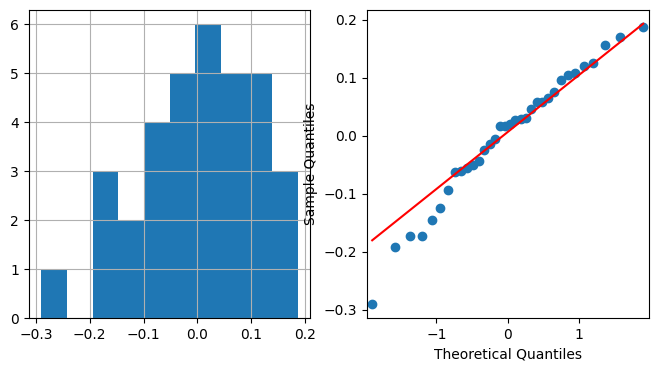

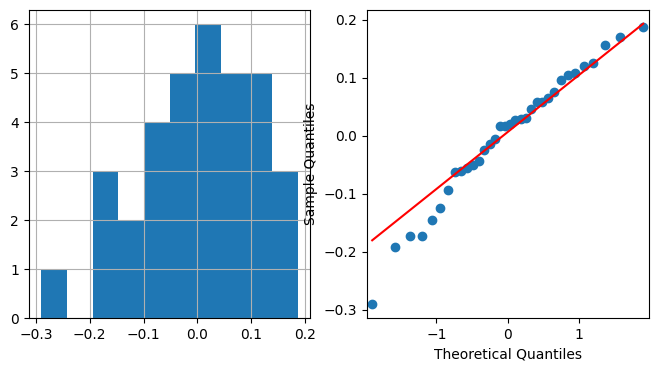

In [8]:
import matplotlib.pyplot as plt

f, axs = plt.subplots(1, 2, figsize=(8,4))
tmp = plt.subplot(121)
antibio_lm.resid.hist()
tmp = plt.subplot(122)
sm.qqplot(antibio_lm.resid, line = "q", ax = tmp)

In [24]:
est1 = antibio_lm.params.iloc[2] - antibio_lm.params[1]
MSW = antibio_lm.mse_resid
df = antibio_lm.df_resid
q1 = stats.t.ppf(0.975, df)

lower_ci = est1 - q1 * np.sqrt(MSW * (1/6 + 1/6))
upper_ci = est1 + q1 * np.sqrt(MSW * (1/6 + 1/6))
print(f"""The 95% CI for the diff. between Enrofloxacin and control is
({lower_ci:.3f}, {upper_ci:.3f}).""")

The 95% CI for the diff. between Enrofloxacin and control is
(-0.037, 0.251).


C:\Users\sad\AppData\Local\Temp\ipykernel_2480\3314165459.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  est1 = antibio_lm.params.iloc[2] - antibio_lm.params[1]


In [25]:
c1 = np.array([-1, 0.5, 0.5])
n_vals = np.array([6, 6, 6,])
L = np.sum(c1 * antibio_lm.params.iloc[2:5])
MSW = antibio_lm.mse_resid
df = antibio_lm.df_resid
q1 = -stats.t.ppf(0.025, df)
se1 = np.sqrt(MSW*np.sum(c1**2 / n_vals))
lower_ci = L - q1*se1
upper_ci = L + q1*se1
print(f"""The 95% CI for the diff. between the two groups is
({lower_ci:.3f}, {upper_ci:.3f}).""")

The 95% CI for the diff. between the two groups is
(0.083, 0.332).


In [26]:
import statsmodels.stats.multicomp as mc
cp = mc.MultiComparison(antibio.org, antibio.type)
tk = cp.tukeyhsd()
print(tk)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
 Alfacyp  Control  -0.2917 0.0035 -0.5065 -0.0769   True
 Alfacyp Enroflox   -0.185 0.1226 -0.3998  0.0298  False
 Alfacyp Fenbenda  -0.0617 0.9488 -0.2765  0.1531  False
 Alfacyp Ivermect   0.1067 0.6563 -0.1081  0.3215  False
 Alfacyp Spiramyc    -0.04 0.9954 -0.2801  0.2001  False
 Control Enroflox   0.1067 0.6563 -0.1081  0.3215  False
 Control Fenbenda     0.23 0.0305  0.0152  0.4448   True
 Control Ivermect   0.3983 0.0001  0.1835  0.6131   True
 Control Spiramyc   0.2517 0.0358  0.0115  0.4918   True
Enroflox Fenbenda   0.1233 0.5094 -0.0915  0.3381  False
Enroflox Ivermect   0.2917 0.0035  0.0769  0.5065   True
Enroflox Spiramyc    0.145 0.4549 -0.0951  0.3851  False
Fenbenda Ivermect   0.1683 0.1923 -0.0465  0.3831  False
Fenbenda Spiramyc   0.0217 0.9998 -0.2185  0.2618  False
Ivermect Spiramyc  -0.1467 0.44

In [27]:
out = [x[1] for x in antibio.org.groupby(antibio.type)]
kw_out = stats.kruskal(*out)
print(f"""The test statistic is {kw_out.statistic:.3f},
the p-value is {kw_out.pvalue:.3f}.""")

The test statistic is 19.645,
the p-value is 0.001.
